  0D Global Model — Argon/Oxygen Mixed Discharge
  Lee & Lieberman Framework (JVST A 13, 368)

Running global sweep for 40% Ar / 60% O2 at 100.0W...
Pressure [mTorr] |  Te [eV] |   ne [cm^-3] |   O- [cm^-3]
------------------------------------------------------------
            1.00 |     5.76 |     2.56e+10 |     2.35e+09
            1.14 |     5.45 |     2.76e+10 |     2.56e+09
            1.31 |     5.17 |     2.96e+10 |     2.79e+09
            1.50 |     4.92 |     3.18e+10 |     3.04e+09
            1.72 |     4.68 |     3.40e+10 |     3.31e+09
            1.96 |     4.47 |     3.64e+10 |     3.59e+09
            2.25 |     4.27 |     3.90e+10 |     3.89e+09
            2.57 |     4.08 |     4.17e+10 |     4.21e+09
            2.94 |     3.91 |     4.46e+10 |     4.55e+09
            3.37 |     3.75 |     4.78e+10 |     4.92e+09
            3.86 |     3.59 |     5.13e+10 |     5.31e+09
            4.41 |     3.45 |     5.50e+10 |     5.72e+09
            5.05 |     3.32 |     5.

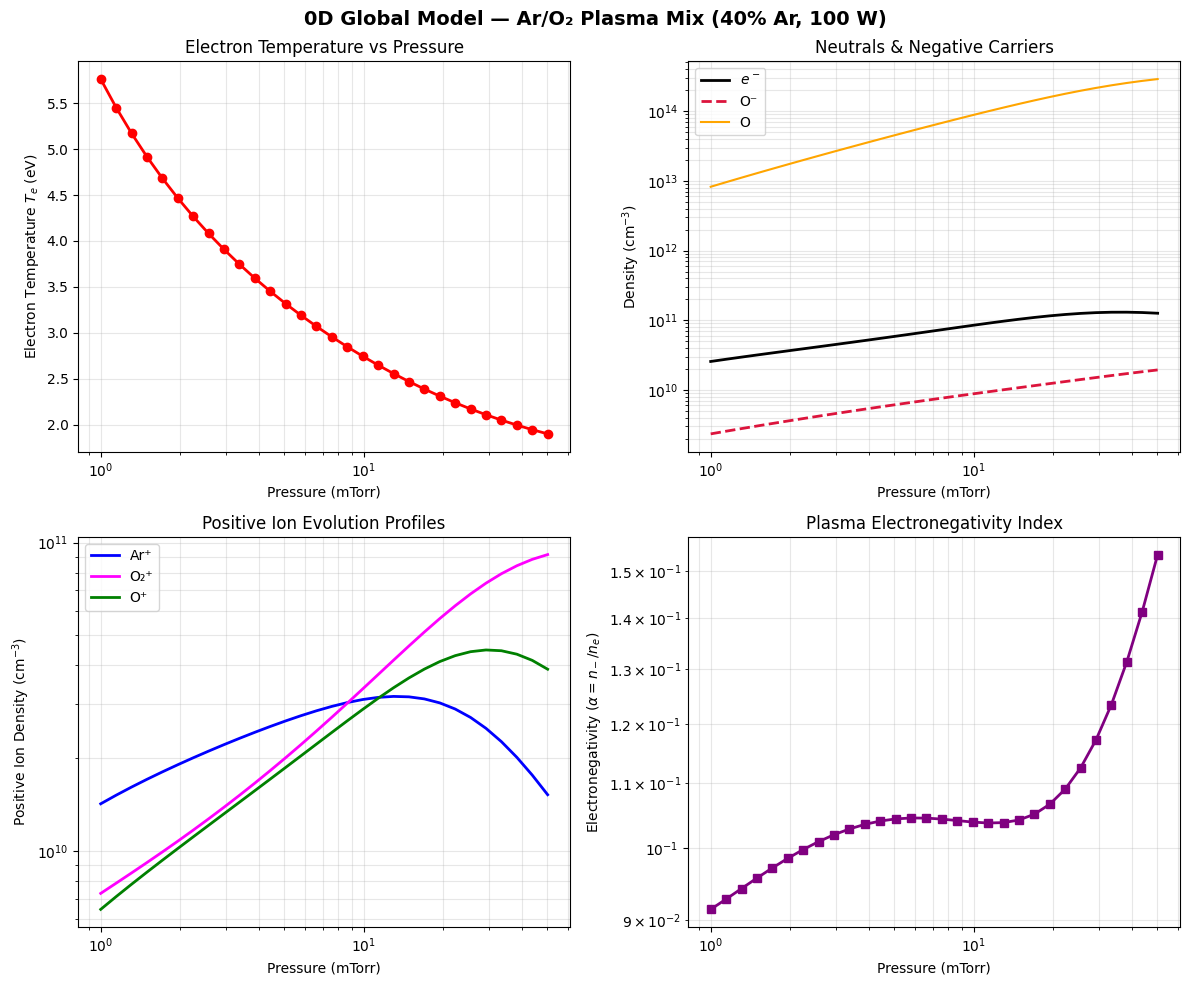

In [1]:
"""
=============================================================================
  0D Global Model for Mixed Argon / Oxygen High-Density Plasma Discharge
  Based on: Lee & Lieberman, J. Vac. Sci. Technol. A 13, 368 (1995)

  Extends the 0D electropositive model into an electronegative multi-ion matrix:
  Tracks: Ar, Ar*, O2, O, Ar+, O2+, O+, O-, and electrons with step continuation.
=============================================================================
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root
from scipy.constants import e, k, m_e, m_u, pi
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# CONSTANTS & REACTOR GEOMETRY
# ============================================================
e_charge = e
kB       = k
M_Ar     = 39.948 * m_u
M_O2     = 31.998 * m_u
M_O      = 15.999 * m_u

# Standard TCP geometry configurations from Lee & Lieberman
L = 0.075       # 7.5 cm
R = 0.1525      # 15.25 cm
V = pi * R**2 * L
A_total = 2*pi*R*L + 2*pi*R**2

# Wall recombination probability for oxygen atoms
GAMMA_REC = 0.01  # Typical clean quartz wall value

print("=" * 60)
print("  0D Global Model — Argon/Oxygen Mixed Discharge")
print("  Lee & Lieberman Framework (JVST A 13, 368)")
print("=" * 60)

# ============================================================
# ANALYTIC RATE COEFFICIENTS (Lee & Lieberman Table III & IV)
# ============================================================
def get_rate_coefficients(Te):
    """
    Computes electron impact and heavy-particle rates (converted to m^3/s).
    Te represents electron temperature in eV.
    """
    # --- Argon Electron Impact Reactions (Table III) ---
    k_iz_Ar   = 1.23e-7 * np.exp(-18.68 / Te) * 1e-6    # e + Ar -> Ar+ + 2e
    k_exc_Ar  = 3.71e-8 * np.exp(-15.06 / Te) * 1e-6    # e + Ar -> Ar* + e
    k_iz_Arst = 2.05e-7 * np.exp(-4.95 / Te) * 1e-6     # e + Ar* -> Ar+ + 2e
    k_de_Arst = 2.0e-7 * 1e-6                           # e + Ar* -> Ar + e (de-excitation)
    k_pool_Ar = 6.2e-16                                 # Ar* + Ar* -> Ar+ + Ar + e

    # --- Oxygen Electron Impact Reactions (Table IV) ---
    k_iz_O2   = 9.0e-9 * (Te**0.7) * np.exp(-12.6 / Te) * 1e-6   # e + O2 -> O2+ + 2e
    k_dis_O2  = 5.37e-9 * (Te**0.52) * np.exp(-6.13 / Te) * 1e-6 # e + O2 -> O + O + e
    k_att_O2  = 1.12e-9 * (Te**-0.65) * np.exp(-5.81 / Te) * 1e-6 # e + O2 -> O + O- (Attachment)
    k_iz_O    = 9.0e-9 * (Te**0.7) * np.exp(-13.6 / Te) * 1e-6   # e + O -> O+ + 2e

    # --- Cross-Species Heavy Particle Reactions (Table VI) ---
    k_rec_O_Ar    = 2.70e-7 * 1e-6    # O- + Ar+ -> Ar + O
    k_rec_O_O2p   = 2.0e-7 * 1e-6     # O- + O2+ -> O2 + O
    k_rec_O_Op    = 2.0e-7 * 1e-6     # O- + O+ -> O + O
    k_cx_Arp_O2   = 1.20e-11 * 1e-6   # Ar+ + O2 -> O2+ + Ar
    k_cx_Arp_O    = 1.20e-11 * 1e-6   # Ar+ + O -> O+ + Ar
    k_q_Arst_O2   = 1.12e-9 * 1e-6    # O2 + Ar* -> Ar + O2
    k_q_Arst_O    = 8.10e-12 * 1e-6   # O + Ar* -> Ar + O
    k_dis_Arst_O2 = 5.80e-11 * 1e-6   # O2 + Ar* -> Ar + O + O

    # Detachment by neutrals
    k_det_O       = 1.60e-10 * 1e-6   # O- + O -> O2 + e

    return {
        'k_iz_Ar': k_iz_Ar, 'k_exc_Ar': k_exc_Ar, 'k_iz_Arst': k_iz_Arst, 'k_de_Arst': k_de_Arst, 'k_pool_Ar': k_pool_Ar,
        'k_iz_O2': k_iz_O2, 'k_dis_O2': k_dis_O2, 'k_att_O2': k_att_O2, 'k_iz_O': k_iz_O,
        'k_rec_O_Ar': k_rec_O_Ar, 'k_rec_O_O2p': k_rec_O_O2p, 'k_rec_O_Op': k_rec_O_Op,
        'k_cx_Arp_O2': k_cx_Arp_O2, 'k_cx_Arp_O': k_cx_Arp_O, 'k_q_Arst_O2': k_q_Arst_O2,
        'k_q_Arst_O': k_q_Arst_O, 'k_dis_Arst_O2': k_dis_Arst_O2, 'k_det_O': k_det_O
    }

# ============================================================
# INTERPOLATED ELECTRONEGATIVE TRANSPORT FACTORS
# ============================================================
def electronegative_geometry_factors(Te, p_mTorr, alpha):
    """
    Calculates effective area loss scaling (h-factors) optimized for
    electronegative plasmas according to Lee & Lieberman's appendix equations.
    """
    T_neutral = 600.0
    p_Pa = p_mTorr * 0.1333
    n_g = p_Pa / (kB * T_neutral)

    # Composite ion transport parameters using oxygen background mfp
    sigma_cross = 4.0e-19
    lambda_i = 1.0 / (np.sqrt(2) * sigma_cross * n_g)

    # Average Bohm Velocity over core ionic components
    uB = np.sqrt(e_charge * Te / M_O2)
    nu_in = uB / lambda_i
    Da = (e_charge * Te) / (M_O2 * nu_in)

    # Base electropositive h-factors
    hL_ep = 0.86 / np.sqrt(3 + L / (2 * lambda_i) + (0.86 * L * uB / (pi * Da))**2)
    hR_ep = 0.8 / np.sqrt(4 + R / lambda_i + (0.8 * R * uB / (2.405 * 0.5191 * Da))**2)

    if alpha < 0.05:
        return hL_ep, hR_ep

    # Electronegative parabolic profiling modifications
    hL_en = hL_ep / np.sqrt(1 + alpha)
    hR_en = hR_ep / np.sqrt(1 + alpha)

    return hL_en, hR_en

# ============================================================
# CORE CONVERGENCE SOLVER INTERFACE
# ============================================================
def solve_ar_o2_system(p_mTorr, P_abs_W, flow_fraction_Ar=0.5, x0_guess=None):
    """
    Solves the self-consistent multi-component particle balance coupled with
    the total electron/ion global energy balance matrix equations.
    Accepts x0_guess to allow dynamic continuation tracking.
    """
    T_neutral = 600.0
    n_total_neutrals = (p_mTorr * 0.1333) / (kB * T_neutral)

    # Set default starting guess if none provided via continuation loop
    if x0_guess is None:
        x0 = [3.5, 1e17, 1e15, 1e19, 5e16, 5e16, 5e16, 1e16]
    else:
        x0 = x0_guess

    def system_residuals(x):
        Te, ne, n_Arst, n_O, n_Ar_p, n_O2_p, n_O_p, n_O_m = x

        # Enforce physical constraints via clipping during root iterations
        Te = max(Te, 0.1); ne = max(ne, 1e12); n_Arst = max(n_Arst, 1e10)
        n_O = max(n_O, 1e12); n_Ar_p = max(n_Ar_p, 1e12); n_O2_p = max(n_O2_p, 1e12)
        n_O_p = max(n_O_p, 1e12); n_O_m = max(n_O_m, 1e10)

        # Compute dynamic neutral ground states by mass balances
        n_Ar = max(n_total_neutrals * flow_fraction_Ar - n_Arst - n_Ar_p, 1e11)
        n_O2 = max(n_total_neutrals * (1.0 - flow_fraction_Ar) - 0.5 * n_O - n_O2_p - n_O_p, 1e11)

        # Extraction of updated coefficients
        rates = get_rate_coefficients(Te)
        alpha = n_O_m / ne
        hL, hR = electronegative_geometry_factors(Te, p_mTorr, alpha)

        # Effective areas based on h-factor profile modifications
        Aeff = 2 * pi * R**2 * hL + 2 * pi * R * L * hR

        # Characteristic Escape Velocities (Bohm)
        uB_Ar = np.sqrt(e_charge * Te / M_Ar)
        uB_O2 = np.sqrt(e_charge * Te / M_O2)
        uB_O  = np.sqrt(e_charge * Te / M_O)

        # Neutral Wall Loss Rate Coefficient for Dissociated Atomic Oxygen
        v_th_O = np.sqrt(8 * kB * T_neutral / (pi * M_O))
        k_loss_O_wall = (GAMMA_REC * v_th_O * A_total) / (4 * V)

        # --- 1. Neutral Phase Balances ---
        res_Arst = (rates['k_exc_Ar'] * n_Ar * ne
                    - rates['k_iz_Arst'] * n_Arst * ne
                    - rates['k_de_Arst'] * n_Arst * ne
                    - 2 * rates['k_pool_Ar'] * (n_Arst**2)
                    - rates['k_q_Arst_O2'] * n_Arst * n_O2
                    - rates['k_q_Arst_O'] * n_Arst * n_O
                    - rates['k_dis_Arst_O2'] * n_Arst * n_O2)

        res_O = (2 * rates['k_dis_O2'] * n_O2 * ne
                 + rates['k_att_O2'] * n_O2 * ne
                 + 2 * rates['k_dis_Arst_O2'] * n_Arst * n_O2
                 - rates['k_iz_O'] * n_O * ne
                 - rates['k_cx_Arp_O'] * n_Ar_p * n_O
                 - rates['k_det_O'] * n_O_m * n_O
                 - k_loss_O_wall * n_O)

        # --- 2. Positive & Negative Ion Balance Iterations ---
        res_Ar_p = (rates['k_iz_Ar'] * n_Ar * ne
                    + rates['k_iz_Arst'] * n_Arst * ne
                    + rates['k_pool_Ar'] * (n_Arst**2)
                    - rates['k_cx_Arp_O2'] * n_Ar_p * n_O2
                    - rates['k_cx_Arp_O'] * n_Ar_p * n_O
                    - rates['k_rec_O_Ar'] * n_Ar_p * n_O_m
                    - (Aeff * uB_Ar / V) * n_Ar_p)

        res_O2_p = (rates['k_iz_O2'] * n_O2 * ne
                    + rates['k_cx_Arp_O2'] * n_Ar_p * n_O2
                    - rates['k_rec_O_O2p'] * n_O2_p * n_O_m
                    - (Aeff * uB_O2 / V) * n_O2_p)

        res_O_p = (rates['k_iz_O'] * n_O * ne
                   + rates['k_cx_Arp_O'] * n_Ar_p * n_O
                   - rates['k_rec_O_Op'] * n_O_p * n_O_m
                   - (Aeff * uB_O / V) * n_O_p)

        res_O_m = (rates['k_att_O2'] * n_O2 * ne
                   - rates['k_det_O'] * n_O_m * n_O
                   - rates['k_rec_O_Ar'] * n_Ar_p * n_O_m
                   - rates['k_rec_O_O2p'] * n_O2_p * n_O_m
                   - rates['k_rec_O_Op'] * n_O_p * n_O_m)

        # --- 3. Closure/Consistency Equations ---
        res_neutrality = (n_Ar_p + n_O2_p + n_O_p) - (ne + n_O_m)

        # --- 4. Global Electron/Ion Power Balance ---
        eps_iz_Ar = 15.76; eps_exc_Ar = 11.56
        eps_iz_O2 = 12.0; eps_dis_O2 = 5.6; eps_att_O2 = 4.0
        eps_iz_O  = 13.6

        P_loss_vol = e_charge * V * ne * (
            rates['k_iz_Ar'] * n_Ar * eps_iz_Ar +
            rates['k_exc_Ar'] * n_Ar * eps_exc_Ar +
            rates['k_iz_O2'] * n_O2 * eps_iz_O2 +
            rates['k_dis_O2'] * n_O2 * eps_dis_O2 +
            rates['k_att_O2'] * n_O2 * eps_att_O2 +
            rates['k_iz_O'] * n_O * eps_iz_O
        )

        P_loss_walls = e_charge * Aeff * (
            n_Ar_p * uB_Ar * (7.0 * Te) +
            n_O2_p * uB_O2 * (7.0 * Te) +
            n_O_p * uB_O * (7.0 * Te)
        )

        res_power = P_abs_W - (P_loss_vol + P_loss_walls)

        return [res_Arst, res_O, res_Ar_p, res_O2_p, res_O_p, res_O_m, res_neutrality, res_power]

    sol = root(system_residuals, x0, method='hybr', tol=1e-7)
    return sol.x if sol.success else np.full(8, np.nan)

# ============================================================
# SWEEP EXECUTION & PLOTTING PIPELINE
# ============================================================
def run_ar_o2_simulation():
    pressures = np.logspace(0, 1.7, 30) # 1 mTorr to ~50 mTorr range
    absorbed_power = 100.0            # 100W configuration
    mix_ratio = 0.40                  # 40% Argon / 60% Oxygen mix

    successful_pressures = []
    Te_arr, ne_arr, nO_arr, nArp_arr, nO2p_arr, nOp_arr, nOm_arr = [], [], [], [], [], [], []

    # Baseline guess array for the initial low-pressure index (1 mTorr)
    current_guess = [5.5, 2.5e16, 1e14, 1e18, 1e16, 1e16, 5e15, 2e15]

    print(f"\nRunning global sweep for {mix_ratio*100:.0f}% Ar / {(1-mix_ratio)*100:.0f}% O2 at {absorbed_power}W...")
    print(f"{'Pressure [mTorr]':>16} | {'Te [eV]':>8} | {'ne [cm^-3]':>12} | {'O- [cm^-3]':>12}")
    print("-" * 60)

    for p in pressures:
        res = solve_ar_o2_system(p, absorbed_power, flow_fraction_Ar=mix_ratio, x0_guess=current_guess)

        if np.isnan(res[0]):
            continue

        # Update the evolutionary guess vector for the NEXT pressure loop iteration
        current_guess = list(res)

        successful_pressures.append(p)
        Te_arr.append(res[0])
        ne_arr.append(res[1] * 1e-6)   # convert to cm^-3
        nO_arr.append(res[3] * 1e-6)
        nArp_arr.append(res[4] * 1e-6)
        nO2p_arr.append(res[5] * 1e-6)
        nOp_arr.append(res[6] * 1e-6)
        nOm_arr.append(res[7] * 1e-6)

        print(f"{p:16.2f} | {res[0]:8.2f} | {res[1]*1e-6:12.2e} | {res[7]*1e-6:12.2e}")

    if not successful_pressures:
        print("Error: Solver failed to converge at any pressure points.")
        return

    # Plot results mimicking paper style trends
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle(f'0D Global Model — Ar/O₂ Plasma Mix ({mix_ratio*100:.0f}% Ar, {absorbed_power:.0f} W)',
                 fontsize=14, fontweight='bold')

    # Ax 0: Electron Temperature
    axes[0, 0].semilogx(successful_pressures, Te_arr, 'r-o', lw=2)
    axes[0, 0].set_ylabel('Electron Temperature $T_e$ (eV)')
    axes[0, 0].set_xlabel('Pressure (mTorr)')
    axes[0, 0].grid(True, which='both', alpha=0.3)
    axes[0, 0].set_title('Electron Temperature vs Pressure')

    # Ax 1: Component Densities
    axes[0, 1].loglog(successful_pressures, ne_arr, 'black', label='$e^-$', lw=2)
    axes[0, 1].loglog(successful_pressures, nOm_arr, 'crimson', linestyle='--', label='O⁻', lw=2)
    axes[0, 1].loglog(successful_pressures, nO_arr, 'orange', label='O', lw=1.5)
    axes[0, 1].set_ylabel(r'Density ($\mathrm{cm}^{-3}$)')
    axes[0, 1].set_xlabel('Pressure (mTorr)')
    axes[0, 1].legend()
    axes[0, 1].grid(True, which='both', alpha=0.3)
    axes[0, 1].set_title('Neutrals & Negative Carriers')

    # Ax 2: Positive Ion Speciation Matrix
    axes[1, 0].loglog(successful_pressures, nArp_arr, 'blue', label='Ar⁺', lw=2)
    axes[1, 0].loglog(successful_pressures, nO2p_arr, 'magenta', label='O₂⁺', lw=2)
    axes[1, 0].loglog(successful_pressures, nOp_arr, 'green', label='O⁺', lw=2)
    axes[1, 0].set_ylabel(r'Positive Ion Density ($\mathrm{cm}^{-3}$)')
    axes[1, 0].set_xlabel('Pressure (mTorr)')
    axes[1, 0].legend()
    axes[1, 0].grid(True, which='both', alpha=0.3)
    axes[1, 0].set_title('Positive Ion Evolution Profiles')

    # Ax 3: Electronegativity Alpha Plot
    alpha_arr = np.array(nOm_arr) / np.array(ne_arr)
    axes[1, 1].loglog(successful_pressures, alpha_arr, 'purple', lw=2, marker='s')
    axes[1, 1].set_ylabel(r'Electronegativity ($\alpha = n_- / n_e$)')
    axes[1, 1].set_xlabel('Pressure (mTorr)')
    axes[1, 1].grid(True, which='both', alpha=0.3)
    axes[1, 1].set_title('Plasma Electronegativity Index')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_ar_o2_simulation()

Successfully parsed 74 cross section blocks from 'Cross section aro.txt'

Compiling Maxwellian rate lookup tables for Ar/O2 chemistry...
  k_iz_Ar  assembled from: Ar -> Ar^+ (thr=15.76 eV)
  k_iz_Arst compiled matching downshifted step ionization (thr=4.20 eV)
  k_exc_Ar assembled from: Ar -> Ar(1S5) (thr=11.55 eV)
  k_iz_O2  assembled from: O2 -> +ionized O2 (thr=12.07 eV)
  k_dis_O2 assembled from: O2 -> O2( EXC A3 DISOC) (thr=6.10 eV)
  k_iz_O   assembled from: O <-> O+ (thr=13.60 eV)
Multi-species rate dictionary compilation complete.

Initiating Multi-Species Self-Consistent Plasma Sweep...
Pressure [mTorr] |  Te [eV] |   ne [cm^-3] |   O- [cm^-3]
------------------------------------------------------------
            1.00 |     6.91 |     1.13e+11 |     1.08e+10
            1.32 |     6.12 |     1.34e+11 |     1.18e+10
            1.75 |     5.48 |     1.59e+11 |     1.27e+10
            2.31 |     4.93 |     1.87e+11 |     1.36e+10
            3.06 |     4.47 |     2.20e+11 | 

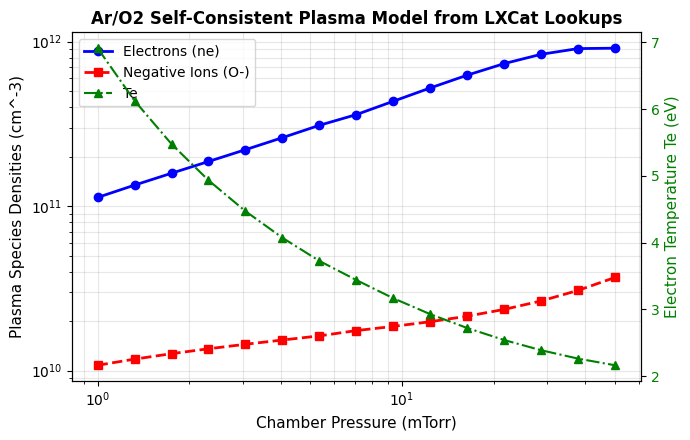

In [3]:
"""
=============================================================================
  0D Global Model for Mixed Argon / Oxygen High-Density Plasma Discharge
  Based on: Lee & Lieberman, J. Vac. Sci. Technol. A 13, 368 (1995)

  Rate coefficients computed dynamically from multi-species LXCat cross sections
  integrated over a Maxwellian EEDF, featuring robust threshold filtering
  to isolate positive physical roots for electronegative chemistry.
=============================================================================
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root
from scipy.interpolate import interp1d
from scipy.constants import e, k, m_e, m_u, pi
import os
import re
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# CONSTANTS & REACTOR GEOMETRY
# ============================================================
e_charge = e
kB       = k
M_Ar     = 39.948 * m_u
M_O2     = 31.998 * m_u
M_O      = 15.999 * m_u

L = 0.075       # 7.5 cm
R = 0.1525      # 15.25 cm
V = pi * R**2 * L
A_total = 2*pi*R*L + 2*pi*R**2
GAMMA_REC = 0.01  # Surface wall recombination coefficient for O atoms

# ---------- SET YOUR MULTI-SPECIES LXCAT FILENAME HERE ----------
LXCAT_FILE = "Cross section aro.txt"
# ----------------------------------------------------------------

# ============================================================
# MULTI-SPECIES LXCAT PARSER
# ============================================================

def parse_multi_species_lxcat(filepath):
    """
    Parses a standard multi-species LXCat file. Handles mixed blocks of
    ELASTIC, EFFECTIVE, EXCITATION, IONIZATION, and ATTACHMENT for Ar, O2, and O.
    """
    if not os.path.isfile(filepath):
        raise FileNotFoundError(
            f"\nFile not found: '{filepath}'. Upload your cross section file."
        )

    with open(filepath, 'r', errors='replace') as fh:
        text = fh.read()

    header_re = re.compile(
        r'^(ELASTIC|EFFECTIVE|EXCITATION|IONIZATION|ATTACHMENT)\s*$', re.MULTILINE
    )
    positions = [(m.group(1), m.start()) for m in header_re.finditer(text)]
    positions.append(('END', len(text)))

    processes = []
    for idx in range(len(positions) - 1):
        block_type, start = positions[idx]
        _, end            = positions[idx + 1]
        lines = text[start:end].splitlines()

        process_str = ''
        threshold   = 0.0
        in_data     = False
        data_rows   = []

        for line in lines[1:]:
            s = line.strip()
            if re.match(r'^-{5,}', s):
                if in_data:
                    break
                in_data = True
                continue

            if in_data:
                parts = s.split()
                if len(parts) == 2:
                    try:
                        data_rows.append((float(parts[0]), float(parts[1])))
                    except ValueError:
                        pass
            else:
                if s and not s.startswith('#'):
                    if not process_str:
                        process_str = s
                    else:
                        parts = s.split()
                        try:
                            # Safely attempt to parse threshold from header lines
                            if block_type not in ('ELASTIC', 'EFFECTIVE') and len(parts) > 0:
                                threshold = float(parts[0])
                        except (ValueError, IndexError):
                            pass

        if not data_rows:
            continue

        energy = np.array([r[0] for r in data_rows])
        sigma  = np.array([r[1] for r in data_rows])
        sigma[energy < threshold] = 0.0

        processes.append(dict(
            type=block_type,
            process=process_str,
            threshold=threshold,
            energy=energy,
            sigma=sigma,
        ))

    print(f"Successfully parsed {len(processes)} cross section blocks from '{filepath}'")
    return processes

# ============================================================
# INTEGRATOR ENGINE & GRID COMPILATION
# ============================================================

_EPS = np.unique(np.concatenate([
    np.linspace(0,   1,    600),
    np.linspace(1,   20,  2000),
    np.linspace(20,  100, 1000),
    np.linspace(100, 1000, 400),
]))

_TE = np.logspace(-1, 2, 300)
_VEL_PREFACTOR = np.sqrt(2.0 * e_charge / m_e)

def _maxwellian(eps, Te):
    return (2.0 / np.sqrt(np.pi)) * Te**(-1.5) * np.sqrt(np.maximum(eps, 0.0)) * np.exp(-np.maximum(eps, 0.0) / Te)

def _k_from_sigma(sigma_fn, Te):
    sv  = sigma_fn(_EPS)
    fMv = _maxwellian(_EPS, Te)
    return max(_VEL_PREFACTOR * np.trapz(sv * np.sqrt(np.maximum(_EPS, 0.0)) * fMv, _EPS), 0.0)

def _make_interp(energy, sigma):
    order = np.argsort(energy)
    return interp1d(energy[order], sigma[order], kind='linear', bounds_error=False, fill_value=(0.0, sigma[order][-1]))

def _build_k_interp(sigma_fn):
    kt = np.array([_k_from_sigma(sigma_fn, T) for T in _TE])
    return interp1d(_TE, kt, kind='linear', bounds_error=False, fill_value=(kt[0], kt[-1]))

# Global lookup dictionary populated by the compiler
_rates_lookup = {}

def load_ar_o2_rates(filepath):
    """
    Parses cross sections for mixed species from the file and builds continuous
    1-D interpolation lookup tables k(Te) with robust physical safety checks.
    """
    global _rates_lookup
    procs = parse_multi_species_lxcat(filepath)

    print("\nCompiling Maxwellian rate lookup tables for Ar/O2 chemistry...")

    # 1. Argon Isolation
    ar_iz = [p for p in procs if p['type'] == 'IONIZATION' and ('Ar' in p['process'] or 'ar' in p['process'])]
    ar_ex = [p for p in procs if p['type'] == 'EXCITATION' and ('Ar' in p['process'] or 'ar' in p['process'])]

    if ar_iz:
        p_ar_iz = min(ar_iz, key=lambda p: abs(p['threshold'] - 15.76))
        _rates_lookup['k_iz_Ar'] = _build_k_interp(_make_interp(p_ar_iz['energy'], p_ar_iz['sigma']))
        print(f"  k_iz_Ar  assembled from: {p_ar_iz['process'][:50]} (thr={p_ar_iz['threshold']:.2f} eV)")

        # Step ionization from metastable levels (Shifted energy axis approach)
        shifted_e = p_ar_iz['energy'] - 11.56
        mask = shifted_e > 0
        if mask.sum() > 1:
            _rates_lookup['k_iz_Arst'] = _build_k_interp(_make_interp(shifted_e[mask], p_ar_iz['sigma'].copy()[mask]))
        print(f"  k_iz_Arst compiled matching downshifted step ionization (thr={max(p_ar_iz['threshold']-11.56, 0):.2f} eV)")

    if ar_ex:
        p_ar_ex = min(ar_ex, key=lambda p: abs(p['threshold'] - 11.56))
        _rates_lookup['k_exc_Ar'] = _build_k_interp(_make_interp(p_ar_ex['energy'], p_ar_ex['sigma']))
        print(f"  k_exc_Ar assembled from: {p_ar_ex['process'][:50]} (thr={p_ar_ex['threshold']:.2f} eV)")

    # 2. Molecular and Atomic Oxygen Isolation
    o2_iz  = [p for p in procs if p['type'] == 'IONIZATION' and 'O2' in p['process']]
    o2_dis = [p for p in procs if p['type'] == 'EXCITATION' and 'O2' in p['process']]

    # CRITICAL PHYSICAL FILTER: Filter for resonant dissociative attachment (thr > 3 eV)
    o2_att = [p for p in procs if p['type'] == 'ATTACHMENT' and p['threshold'] > 3.0]
    if not o2_att:
        o2_att = [p for p in procs if 'O-' in p['process'] and p['threshold'] > 3.0]

    o_iz   = [p for p in procs if p['type'] == 'IONIZATION' and p['process'].strip().startswith('O')]
    o_iz   = [p for p in o_iz if 'O2' not in p['process']]

    if o2_iz:
        p_o2_iz = o2_iz[0]
        _rates_lookup['k_iz_O2'] = _build_k_interp(_make_interp(p_o2_iz['energy'], p_o2_iz['sigma']))
        print(f"  k_iz_O2  assembled from: {p_o2_iz['process'][:50]} (thr={p_o2_iz['threshold']:.2f} eV)")

    if o2_dis:
        p_o2_dis = min(o2_dis, key=lambda p: abs(p['threshold'] - 6.0))
        _rates_lookup['k_dis_O2'] = _build_k_interp(_make_interp(p_o2_dis['energy'], p_o2_dis['sigma']))
        print(f"  k_dis_O2 assembled from: {p_o2_dis['process'][:50]} (thr={p_o2_dis['threshold']:.2f} eV)")

    if o2_att:
        p_o2_att = min(o2_att, key=lambda p: abs(p['threshold'] - 5.0))
        _rates_lookup['k_att_O2'] = _build_k_interp(_make_interp(p_o2_att['energy'], p_o2_att['sigma']))
        print(f"  k_att_O2 assembled from: {p_o2_att['process'][:50]} (thr={p_o2_att['threshold']:.2f} eV)")
    else:
        print("  WARNING: No resonant O2 attachment block found with threshold > 3 eV! Using analytic fallback.")

    if o_iz:
        p_o_iz = o_iz[0]
        _rates_lookup['k_iz_O'] = _build_k_interp(_make_interp(p_o_iz['energy'], p_o_iz['sigma']))
        print(f"  k_iz_O   assembled from: {p_o_iz['process'][:50]} (thr={p_o_iz['threshold']:.2f} eV)")

    print("Multi-species rate dictionary compilation complete.\n")

# ============================================================
# CHEMISTRY RATE EVALUATOR
# ============================================================

def evaluate_integrated_rates(Te):
    """
    Queries Lookups from lookups, defaulting to historical baselines if
    any optional interaction parameters are absent.
    """
    k_iz_Ar  = float(_rates_lookup['k_iz_Ar'](Te)) if 'k_iz_Ar' in _rates_lookup else 1.23e-13 * np.exp(-18.68/Te)
    k_exc_Ar = float(_rates_lookup['k_exc_Ar'](Te)) if 'k_exc_Ar' in _rates_lookup else 3.71e-14 * np.exp(-15.06/Te)
    k_iz_Arst= float(_rates_lookup['k_iz_Arst'](Te)) if 'k_iz_Arst' in _rates_lookup else 2.05e-13 * np.exp(-4.95/Te)
    k_iz_O2  = float(_rates_lookup['k_iz_O2'](Te)) if 'k_iz_O2' in _rates_lookup else 1.0e-13 * np.exp(-12.1/Te)
    k_dis_O2 = float(_rates_lookup['k_dis_O2'](Te)) if 'k_dis_O2' in _rates_lookup else 1.5e-13 * np.exp(-6.0/Te)
    k_att_O2 = float(_rates_lookup['k_att_O2'](Te)) if 'k_att_O2' in _rates_lookup else 1.2e-15 * np.exp(-4.5/Te)
    k_iz_O   = float(_rates_lookup['k_iz_O'](Te)) if 'k_iz_O' in _rates_lookup else 1.1e-13 * np.exp(-13.6/Te)

    return {
        'k_iz_Ar': k_iz_Ar, 'k_exc_Ar': k_exc_Ar, 'k_iz_Arst': k_iz_Arst,
        'k_iz_O2': k_iz_O2, 'k_dis_O2': k_dis_O2, 'k_att_O2': k_att_O2, 'k_iz_O': k_iz_O,
        'k_de_Arst': 2.0e-13,
        'k_pool_Ar': 6.2e-16,
        'k_rec_O_Ar': 2.7e-13,
        'k_rec_O_O2p': 2.0e-13,
        'k_rec_O_Op': 2.0e-13,
        'k_cx_Arp_O2': 1.2e-17,
        'k_cx_Arp_O': 1.2e-17,
        'k_q_Arst_O2': 1.12e-15,
        'k_q_Arst_O': 8.1e-18,
        'k_dis_Arst_O2': 5.8e-17,
        'k_det_O': 1.6e-16
    }

# ============================================================
# ELECTRONEGATIVE PROFILE TRANSPORT
# ============================================================

def electronegative_geometry_factors(Te, p_mTorr, alpha):
    T_neutral = 600.0
    p_Pa = p_mTorr * 0.1333
    n_g = p_Pa / (kB * T_neutral)
    sigma_cross = 4.0e-19
    lambda_i = 1.0 / (np.sqrt(2) * sigma_cross * n_g)
    uB = np.sqrt(e_charge * Te / M_O2)
    nu_in = uB / lambda_i
    Da = (e_charge * Te) / (M_O2 * nu_in)
    hL_ep = 0.86 / np.sqrt(3 + L / (2 * lambda_i) + (0.86 * L * uB / (pi * Da))**2)
    hR_ep = 0.8 / np.sqrt(4 + R / lambda_i + (0.8 * R * uB / (2.405 * 0.5191 * Da))**2)
    if alpha < 0.05:
        return hL_ep, hR_ep
    return hL_ep / np.sqrt(1 + alpha), hR_ep / np.sqrt(1 + alpha)

# ============================================================
# COUPLING RESIDUAL SOLVER FOR THE SYSTEM MATRIX
# ============================================================

def solve_ar_o2_system(p_mTorr, P_abs_W, flow_fraction_Ar=0.5, x0_guess=None):
    T_neutral = 600.0
    n_total_neutrals = (p_mTorr * 0.1333) / (kB * T_neutral)

    # State Vector: [Te, ne, n_Arst, n_O, n_Ar_p, n_O2_p, n_O_p, n_O_m]
    x0 = [4.0, 1e17, 1e14, 1e18, 5e16, 5e16, 1e16, 1e16] if x0_guess is None else x0_guess

    def system_residuals(x):
        Te, ne, n_Arst, n_O, n_Ar_p, n_O2_p, n_O_p, n_O_m = x

        # DOUBLE INSULATION: Constrain intermediate iterations to positive domains
        Te = max(Te, 0.1); ne = max(ne, 1e11); n_Arst = max(n_Arst, 1e10)
        n_O = max(n_O, 1e12); n_Ar_p = max(n_Ar_p, 1e11); n_O2_p = max(n_O2_p, 1e11)
        n_O_p = max(n_O_p, 1e11); n_O_m = max(n_O_m, 1e10)

        n_Ar = max(n_total_neutrals * flow_fraction_Ar - n_Arst - n_Ar_p, 1e11)
        n_O2 = max(n_total_neutrals * (1.0 - flow_fraction_Ar) - 0.5 * n_O - n_O2_p - n_O_p, 1e11)

        rates = evaluate_integrated_rates(Te)
        alpha = n_O_m / ne
        hL, hR = electronegative_geometry_factors(Te, p_mTorr, alpha)

        Aeff = 2 * pi * R**2 * hL + 2 * pi * R * L * hR
        uB_Ar = np.sqrt(e_charge * Te / M_Ar)
        uB_O2 = np.sqrt(e_charge * Te / M_O2)
        uB_O  = np.sqrt(e_charge * Te / M_O)

        v_th_O = np.sqrt(8 * kB * T_neutral / (pi * M_O))
        k_loss_O_wall = (GAMMA_REC * v_th_O * A_total) / (4 * V)

        # Balance 1: Argon Metastable Density
        res_Arst = (rates['k_exc_Ar'] * n_Ar * ne
                    - rates['k_iz_Arst'] * n_Arst * ne
                    - rates['k_de_Arst'] * n_Arst * ne
                    - 2 * rates['k_pool_Ar'] * (n_Arst**2)
                    - rates['k_q_Arst_O2'] * n_Arst * n_O2
                    - rates['k_q_Arst_O'] * n_Arst * n_O
                    - rates['k_dis_Arst_O2'] * n_Arst * n_O2)

        # Balance 2: Atomic Oxygen Gas Density
        res_O = (2 * rates['k_dis_O2'] * n_O2 * ne
                 + rates['k_att_O2'] * n_O2 * ne
                 + 2 * rates['k_dis_Arst_O2'] * n_Arst * n_O2
                 - rates['k_iz_O'] * n_O * ne
                 - rates['k_cx_Arp_O'] * n_Ar_p * n_O
                 - rates['k_det_O'] * n_O_m * n_O
                 - k_loss_O_wall * n_O)

        # Balance 3: Ar+ Ion Profile
        res_Ar_p = (rates['k_iz_Ar'] * n_Ar * ne
                    + rates['k_iz_Arst'] * n_Arst * ne
                    + rates['k_pool_Ar'] * (n_Arst**2)
                    - rates['k_cx_Arp_O2'] * n_Ar_p * n_O2
                    - rates['k_cx_Arp_O'] * n_Ar_p * n_O
                    - rates['k_rec_O_Ar'] * n_Ar_p * n_O_m
                    - (Aeff * uB_Ar / V) * n_Ar_p)

        # Balance 4: O2+ Ion Profile
        res_O2_p = (rates['k_iz_O2'] * n_O2 * ne
                    + rates['k_cx_Arp_O2'] * n_Ar_p * n_O2
                    - rates['k_rec_O_O2p'] * n_O2_p * n_O_m
                    - (Aeff * uB_O2 / V) * n_O2_p)

        # Balance 5: O+ Ion Profile
        res_O_p = (rates['k_iz_O'] * n_O * ne
                   + rates['k_cx_Arp_O'] * n_Ar_p * n_O
                   - rates['k_rec_O_Op'] * n_O_p * n_O_m
                   - (Aeff * uB_O / V) * n_O_p)

        # Balance 6: O- Negative Ion Profile
        res_O_m = (rates['k_att_O2'] * n_O2 * ne
                   - rates['k_det_O'] * n_O_m * n_O
                   - rates['k_rec_O_Ar'] * n_Ar_p * n_O_m
                   - rates['k_rec_O_O2p'] * n_O2_p * n_O_m
                   - rates['k_rec_O_Op'] * n_O_p * n_O_m)

        # Balance 7: Quasi-Neutrality Balance Validation
        res_neutrality = (n_Ar_p + n_O2_p + n_O_p) - (ne + n_O_m)

        # Balance 8: Electron Energy Flow Conservation
        eps_iz_Ar = 15.76; eps_exc_Ar = 11.56
        eps_iz_O2 = 12.0; eps_dis_O2 = 5.6; eps_att_O2 = 4.0
        eps_iz_O  = 13.6

        P_loss_vol = e_charge * V * ne * (
            rates['k_iz_Ar'] * n_Ar * eps_iz_Ar +
            rates['k_exc_Ar'] * n_Ar * eps_exc_Ar +
            rates['k_iz_O2'] * n_O2 * eps_iz_O2 +
            rates['k_dis_O2'] * n_O2 * eps_dis_O2 +
            rates['k_att_O2'] * n_O2 * eps_att_O2 +
            rates['k_iz_O'] * n_O * eps_iz_O
        )

        P_loss_walls = e_charge * Aeff * (
            n_Ar_p * uB_Ar * (7.0 * Te) +
            n_O2_p * uB_O2 * (7.0 * Te) +
            n_O_p * uB_O * (7.0 * Te)
        )

        res_power = P_abs_W - (P_loss_vol + P_loss_walls)

        return [res_Arst, res_O, res_Ar_p, res_O2_p, res_O_p, res_O_m, res_neutrality, res_power]

    # Use the hybridized Powell method for robust transcendental solving
    sol = root(system_residuals, x0, method='hybr', tol=1e-7)
    return sol.x if sol.success else np.full(8, np.nan)

# ============================================================
# MAIN MAIN MAIN EXECUTION PIPELINE
# ============================================================
if __name__ == "__main__":

    # 1. Compile Rate Lookups Dynamically
    load_ar_o2_rates(LXCAT_FILE)

    # 2. Configure Execution Bounds for the Sweep
    pressures = np.logspace(0, 1.7, 15)  # 1 mTorr to 50 mTorr
    absorbed_power = 500.0             # 500 W Absorbed Core RF Power
    argon_mix_fraction = 0.50          # 50% Argon / 50% Oxygen Mix

    p_success, Te_out, ne_out, nOm_out = [], [], [], []
    guess = [4.0, 1e17, 1e14, 1e18, 2e16, 2e16, 1e16, 1e16]

    print("Initiating Multi-Species Self-Consistent Plasma Sweep...")
    print(f"{'Pressure [mTorr]':>16} | {'Te [eV]':>8} | {'ne [cm^-3]':>12} | {'O- [cm^-3]':>12}")
    print("-" * 60)

    for p in pressures:
        res = solve_ar_o2_system(p, absorbed_power, flow_fraction_Ar=argon_mix_fraction, x0_guess=guess)
        if np.isnan(res[0]) or res[1] <= 0 or res[7] <= 0:
            continue # Skip unphysical conversions or failure steps

        guess = list(res) # Track history for continuity
        p_success.append(p)
        Te_out.append(res[0])
        ne_out.append(res[1] * 1e-6)
        nOm_out.append(res[7] * 1e-6)

        print(f"{p:16.2f} | {res[0]:8.2f} | {res[1]*1e-6:12.2e} | {res[7]*1e-6:12.2e}")

    # 3. Render Final Simulation Diagnostics Profile
    if len(p_success) > 0:
        fig, ax1 = plt.subplots(figsize=(7, 4.5))

        ax1.loglog(p_success, ne_out, 'b-o', lw=2, label='Electrons (ne)')
        ax1.loglog(p_success, nOm_out, 'r--s', lw=2, label='Negative Ions (O-)')
        ax1.set_xlabel('Chamber Pressure (mTorr)', fontsize=11)
        ax1.set_ylabel('Plasma Species Densities (cm^-3)', color='k', fontsize=11)
        ax1.tick_params(axis='y', labelcolor='k')
        ax1.grid(True, which='both', alpha=0.3)

        ax2 = ax1.twinx()
        ax2.plot(p_success, Te_out, 'g-.^', lw=1.5, label='Te')
        ax2.set_ylabel('Electron Temperature Te (eV)', color='g', fontsize=11)
        ax2.tick_params(axis='y', labelcolor='g')

        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

        plt.title('Ar/O2 Self-Consistent Plasma Model from LXCat Lookups', fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()
    else:
        print("\nSweep failed to converge. Verify initial tracking matrices or database entries.")

Successfully parsed 74 cross section blocks from 'Cross section aro.txt'

Compiling Maxwellian rate lookup tables for Ar/O2 chemistry...
Multi-species rate dictionary compilation complete.



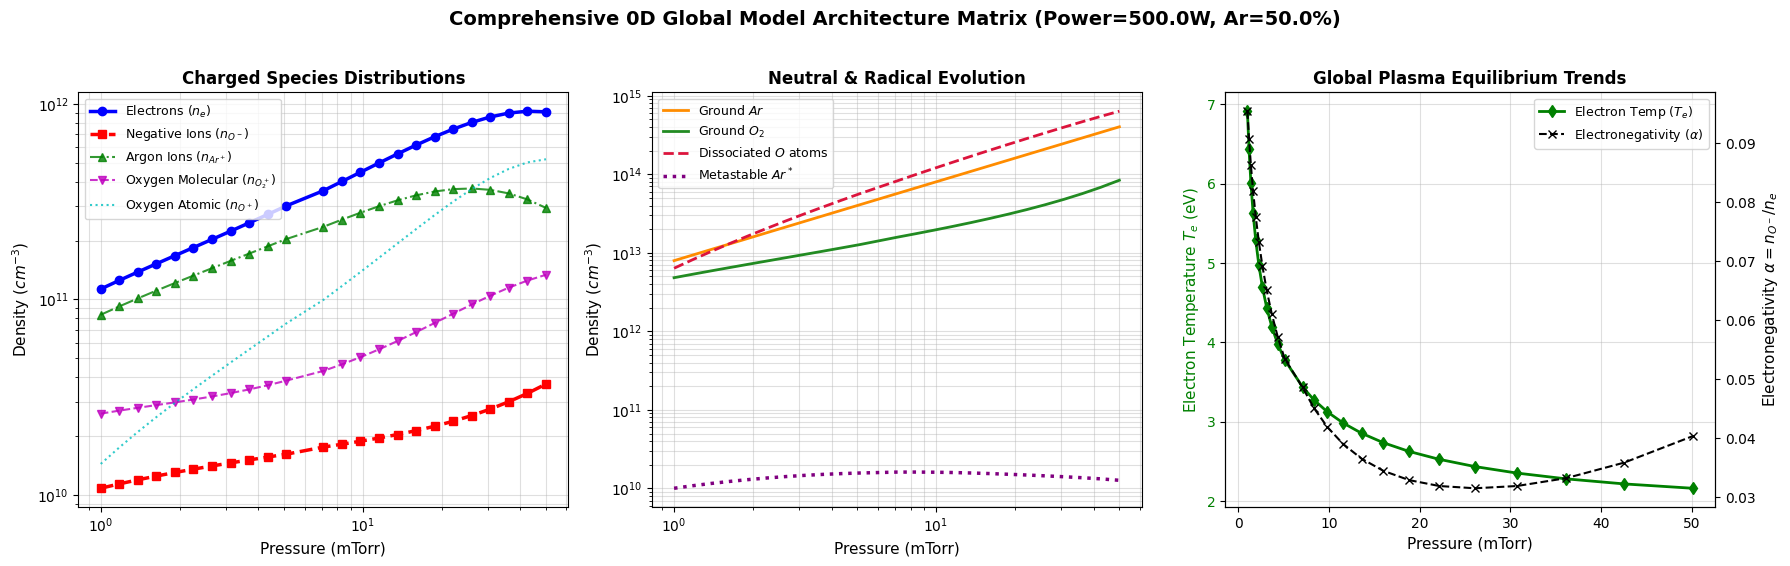

In [4]:
"""
=============================================================================
  0D Global Model for Mixed Argon / Oxygen High-Density Plasma Discharge
  Extended Multi-Plot Diagnostic Dashboard Integration
=============================================================================
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root
from scipy.interpolate import interp1d
from scipy.constants import e, k, m_e, m_u, pi
import os
import re
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# CONSTANTS & REACTOR GEOMETRY
# ============================================================
e_charge = e
kB       = k
M_Ar     = 39.948 * m_u
M_O2     = 31.998 * m_u
M_O      = 15.999 * m_u

L = 0.075       # 7.5 cm
R = 0.1525      # 15.25 cm
V = pi * R**2 * L
A_total = 2*pi*R*L + 2*pi*R**2
GAMMA_REC = 0.01  # Surface wall recombination coefficient for O atoms

LXCAT_FILE = "Cross section aro.txt"

# ============================================================
# MULTI-SPECIES LXCAT PARSER
# ============================================================
def parse_multi_species_lxcat(filepath):
    if not os.path.isfile(filepath):
        raise FileNotFoundError(f"\nFile not found: '{filepath}'. Upload your cross section file.")
    with open(filepath, 'r', errors='replace') as fh:
        text = fh.read()

    header_re = re.compile(r'^(ELASTIC|EFFECTIVE|EXCITATION|IONIZATION|ATTACHMENT)\s*$', re.MULTILINE)
    positions = [(m.group(1), m.start()) for m in header_re.finditer(text)]
    positions.append(('END', len(text)))

    processes = []
    for idx in range(len(positions) - 1):
        block_type, start = positions[idx]
        _, end            = positions[idx + 1]
        lines = text[start:end].splitlines()

        process_str = ''
        threshold   = 0.0
        in_data     = False
        data_rows   = []

        for line in lines[1:]:
            s = line.strip()
            if re.match(r'^-{5,}', s):
                if in_data: break
                in_data = True
                continue

            if in_data:
                parts = s.split()
                if len(parts) == 2:
                    try: data_rows.append((float(parts[0]), float(parts[1])))
                    except ValueError: pass
            else:
                if s and not s.startswith('#'):
                    if not process_str: process_str = s
                    else:
                        parts = s.split()
                        try:
                            if block_type not in ('ELASTIC', 'EFFECTIVE') and len(parts) > 0:
                                threshold = float(parts[0])
                        except (ValueError, IndexError): pass

        if not data_rows: continue
        energy = np.array([r[0] for r in data_rows])
        sigma  = np.array([r[1] for r in data_rows])
        sigma[energy < threshold] = 0.0

        processes.append(dict(type=block_type, process=process_str, threshold=threshold, energy=energy, sigma=sigma))
    print(f"Successfully parsed {len(processes)} cross section blocks from '{filepath}'")
    return processes

# ============================================================
# INTEGRATOR ENGINE & GRID COMPILATION
# ============================================================
_EPS = np.unique(np.concatenate([
    np.linspace(0, 1, 600), np.linspace(1, 20, 2000), np.linspace(20, 100, 1000), np.linspace(100, 1000, 400)
]))
_TE = np.logspace(-1, 2, 300)
_VEL_PREFACTOR = np.sqrt(2.0 * e_charge / m_e)

def _maxwellian(eps, Te):
    return (2.0 / np.sqrt(np.pi)) * Te**(-1.5) * np.sqrt(np.maximum(eps, 0.0)) * np.exp(-np.maximum(eps, 0.0) / Te)

def _k_from_sigma(sigma_fn, Te):
    sv  = sigma_fn(_EPS)
    fMv = _maxwellian(_EPS, Te)
    return max(_VEL_PREFACTOR * np.trapz(sv * np.sqrt(np.maximum(_EPS, 0.0)) * fMv, _EPS), 0.0)

def _make_interp(energy, sigma):
    order = np.argsort(energy)
    return interp1d(energy[order], sigma[order], kind='linear', bounds_error=False, fill_value=(0.0, sigma[order][-1]))

def _build_k_interp(sigma_fn):
    kt = np.array([_k_from_sigma(sigma_fn, T) for T in _TE])
    return interp1d(_TE, kt, kind='linear', bounds_error=False, fill_value=(kt[0], kt[-1]))

_rates_lookup = {}

def load_ar_o2_rates(filepath):
    global _rates_lookup
    procs = parse_multi_species_lxcat(filepath)
    print("\nCompiling Maxwellian rate lookup tables for Ar/O2 chemistry...")

    ar_iz = [p for p in procs if p['type'] == 'IONIZATION' and ('Ar' in p['process'] or 'ar' in p['process'])]
    ar_ex = [p for p in procs if p['type'] == 'EXCITATION' and ('Ar' in p['process'] or 'ar' in p['process'])]

    if ar_iz:
        p_ar_iz = min(ar_iz, key=lambda p: abs(p['threshold'] - 15.76))
        _rates_lookup['k_iz_Ar'] = _build_k_interp(_make_interp(p_ar_iz['energy'], p_ar_iz['sigma']))
        shifted_e = p_ar_iz['energy'] - 11.56
        mask = shifted_e > 0
        if mask.sum() > 1:
            _rates_lookup['k_iz_Arst'] = _build_k_interp(_make_interp(shifted_e[mask], p_ar_iz['sigma'].copy()[mask]))

    if ar_ex:
        p_ar_ex = min(ar_ex, key=lambda p: abs(p['threshold'] - 11.56))
        _rates_lookup['k_exc_Ar'] = _build_k_interp(_make_interp(p_ar_ex['energy'], p_ar_ex['sigma']))

    o2_iz  = [p for p in procs if p['type'] == 'IONIZATION' and 'O2' in p['process']]
    o2_dis = [p for p in procs if p['type'] == 'EXCITATION' and 'O2' in p['process']]
    o2_att = [p for p in procs if p['type'] == 'ATTACHMENT' and p['threshold'] > 3.0]
    if not o2_att:
        o2_att = [p for p in procs if 'O-' in p['process'] and p['threshold'] > 3.0]
    o_iz   = [p for p in procs if p['type'] == 'IONIZATION' and p['process'].strip().startswith('O') and 'O2' not in p['process']]

    if o2_iz: _rates_lookup['k_iz_O2'] = _build_k_interp(_make_interp(o2_iz[0]['energy'], o2_iz[0]['sigma']))
    if o2_dis: _rates_lookup['k_dis_O2'] = _build_k_interp(_make_interp(min(o2_dis, key=lambda p: abs(p['threshold'] - 6.0))['energy'], min(o2_dis, key=lambda p: abs(p['threshold'] - 6.0))['sigma']))
    if o2_att: _rates_lookup['k_att_O2'] = _build_k_interp(_make_interp(min(o2_att, key=lambda p: abs(p['threshold'] - 5.0))['energy'], min(o2_att, key=lambda p: abs(p['threshold'] - 5.0))['sigma']))
    if o_iz: _rates_lookup['k_iz_O'] = _build_k_interp(_make_interp(o_iz[0]['energy'], o_iz[0]['sigma']))
    print("Multi-species rate dictionary compilation complete.\n")

# ============================================================
# CHEMISTRY RATE EVALUATOR & GEOMETRY FACTORING
# ============================================================
def evaluate_integrated_rates(Te):
    k_iz_Ar  = float(_rates_lookup['k_iz_Ar'](Te)) if 'k_iz_Ar' in _rates_lookup else 1.23e-13 * np.exp(-18.68/Te)
    k_exc_Ar = float(_rates_lookup['k_exc_Ar'](Te)) if 'k_exc_Ar' in _rates_lookup else 3.71e-14 * np.exp(-15.06/Te)
    k_iz_Arst= float(_rates_lookup['k_iz_Arst'](Te)) if 'k_iz_Arst' in _rates_lookup else 2.05e-13 * np.exp(-4.95/Te)
    k_iz_O2  = float(_rates_lookup['k_iz_O2'](Te)) if 'k_iz_O2' in _rates_lookup else 1.0e-13 * np.exp(-12.1/Te)
    k_dis_O2 = float(_rates_lookup['k_dis_O2'](Te)) if 'k_dis_O2' in _rates_lookup else 1.5e-13 * np.exp(-6.0/Te)
    k_att_O2 = float(_rates_lookup['k_att_O2'](Te)) if 'k_att_O2' in _rates_lookup else 1.2e-15 * np.exp(-4.5/Te)
    k_iz_O   = float(_rates_lookup['k_iz_O'](Te)) if 'k_iz_O' in _rates_lookup else 1.1e-13 * np.exp(-13.6/Te)

    return {
        'k_iz_Ar': k_iz_Ar, 'k_exc_Ar': k_exc_Ar, 'k_iz_Arst': k_iz_Arst,
        'k_iz_O2': k_iz_O2, 'k_dis_O2': k_dis_O2, 'k_att_O2': k_att_O2, 'k_iz_O': k_iz_O,
        'k_de_Arst': 2.0e-13, 'k_pool_Ar': 6.2e-16, 'k_rec_O_Ar': 2.7e-13, 'k_rec_O_O2p': 2.0e-13,
        'k_rec_O_Op': 2.0e-13, 'k_cx_Arp_O2': 1.2e-17, 'k_cx_Arp_O': 1.2e-17, 'k_q_Arst_O2': 1.12e-15,
        'k_q_Arst_O': 8.1e-18, 'k_dis_Arst_O2': 5.8e-17, 'k_det_O': 1.6e-16
    }

def electronegative_geometry_factors(Te, p_mTorr, alpha):
    T_neutral = 600.0
    p_Pa = p_mTorr * 0.1333
    n_g = p_Pa / (kB * T_neutral)
    sigma_cross = 4.0e-19
    lambda_i = 1.0 / (np.sqrt(2) * sigma_cross * n_g)
    uB = np.sqrt(e_charge * Te / M_O2)
    nu_in = uB / lambda_i
    Da = (e_charge * Te) / (M_O2 * nu_in)
    hL_ep = 0.86 / np.sqrt(3 + L / (2 * lambda_i) + (0.86 * L * uB / (pi * Da))**2)
    hR_ep = 0.8 / np.sqrt(4 + R / lambda_i + (0.8 * R * uB / (2.405 * 0.5191 * Da))**2)
    if alpha < 0.05: return hL_ep, hR_ep
    return hL_ep / np.sqrt(1 + alpha), hR_ep / np.sqrt(1 + alpha)

# ============================================================
# COUPLING RESIDUAL SOLVER
# ============================================================
def solve_ar_o2_system(p_mTorr, P_abs_W, flow_fraction_Ar=0.5, x0_guess=None):
    T_neutral = 600.0
    n_total_neutrals = (p_mTorr * 0.1333) / (kB * T_neutral)
    x0 = [4.0, 1e17, 1e14, 1e18, 5e16, 5e16, 1e16, 1e16] if x0_guess is None else x0_guess

    def system_residuals(x):
        Te, ne, n_Arst, n_O, n_Ar_p, n_O2_p, n_O_p, n_O_m = x
        Te = max(Te, 0.1); ne = max(ne, 1e11); n_Arst = max(n_Arst, 1e10)
        n_O = max(n_O, 1e12); n_Ar_p = max(n_Ar_p, 1e11); n_O2_p = max(n_O2_p, 1e11)
        n_O_p = max(n_O_p, 1e11); n_O_m = max(n_O_m, 1e10)

        n_Ar = max(n_total_neutrals * flow_fraction_Ar - n_Arst - n_Ar_p, 1e11)
        n_O2 = max(n_total_neutrals * (1.0 - flow_fraction_Ar) - 0.5 * n_O - n_O2_p - n_O_p, 1e11)

        rates = evaluate_integrated_rates(Te)
        alpha = n_O_m / ne
        hL, hR = electronegative_geometry_factors(Te, p_mTorr, alpha)

        Aeff = 2 * pi * R**2 * hL + 2 * pi * R * L * hR
        uB_Ar = np.sqrt(e_charge * Te / M_Ar); uB_O2 = np.sqrt(e_charge * Te / M_O2); uB_O = np.sqrt(e_charge * Te / M_O)
        v_th_O = np.sqrt(8 * kB * T_neutral / (pi * M_O))
        k_loss_O_wall = (GAMMA_REC * v_th_O * A_total) / (4 * V)

        res_Arst = (rates['k_exc_Ar'] * n_Ar * ne - rates['k_iz_Arst'] * n_Arst * ne - rates['k_de_Arst'] * n_Arst * ne
                    - 2 * rates['k_pool_Ar'] * (n_Arst**2) - rates['k_q_Arst_O2'] * n_Arst * n_O2
                    - rates['k_q_Arst_O'] * n_Arst * n_O - rates['k_dis_Arst_O2'] * n_Arst * n_O2)

        res_O = (2 * rates['k_dis_O2'] * n_O2 * ne + rates['k_att_O2'] * n_O2 * ne + 2 * rates['k_dis_Arst_O2'] * n_Arst * n_O2
                 - rates['k_iz_O'] * n_O * ne - rates['k_cx_Arp_O'] * n_Ar_p * n_O - rates['k_det_O'] * n_O_m * n_O - k_loss_O_wall * n_O)

        res_Ar_p = (rates['k_iz_Ar'] * n_Ar * ne + rates['k_iz_Arst'] * n_Arst * ne + rates['k_pool_Ar'] * (n_Arst**2)
                    - rates['k_cx_Arp_O2'] * n_Ar_p * n_O2 - rates['k_cx_Arp_O'] * n_Ar_p * n_O - rates['k_rec_O_Ar'] * n_Ar_p * n_O_m - (Aeff * uB_Ar / V) * n_Ar_p)

        res_O2_p = (rates['k_iz_O2'] * n_O2 * ne + rates['k_cx_Arp_O2'] * n_Ar_p * n_O2 - rates['k_rec_O_O2p'] * n_O2_p * n_O_m - (Aeff * uB_O2 / V) * n_O2_p)

        res_O_p = (rates['k_iz_O'] * n_O * ne + rates['k_cx_Arp_O'] * n_Ar_p * n_O - rates['k_rec_O_Op'] * n_O_p * n_O_m - (Aeff * uB_O / V) * n_O_p)

        res_O_m = (rates['k_att_O2'] * n_O2 * ne - rates['k_det_O'] * n_O_m * n_O - rates['k_rec_O_Ar'] * n_Ar_p * n_O_m
                   - rates['k_rec_O_O2p'] * n_O2_p * n_O_m - rates['k_rec_O_Op'] * n_O_p * n_O_m)

        res_neutrality = (n_Ar_p + n_O2_p + n_O_p) - (ne + n_O_m)

        eps_iz_Ar = 15.76; eps_exc_Ar = 11.56; eps_iz_O2 = 12.0; eps_dis_O2 = 5.6; eps_att_O2 = 4.0; eps_iz_O = 13.6
        P_loss_vol = e_charge * V * ne * (
            rates['k_iz_Ar'] * n_Ar * eps_iz_Ar + rates['k_exc_Ar'] * n_Ar * eps_exc_Ar +
            rates['k_iz_O2'] * n_O2 * eps_iz_O2 + rates['k_dis_O2'] * n_O2 * eps_dis_O2 +
            rates['k_att_O2'] * n_O2 * eps_att_O2 + rates['k_iz_O'] * n_O * eps_iz_O
        )
        P_loss_walls = e_charge * Aeff * (n_Ar_p * uB_Ar * (7.0 * Te) + n_O2_p * uB_O2 * (7.0 * Te) + n_O_p * uB_O * (7.0 * Te))
        res_power = P_abs_W - (P_loss_vol + P_loss_walls)

        return [res_Arst, res_O, res_Ar_p, res_O2_p, res_O_p, res_O_m, res_neutrality, res_power]

    sol = root(system_residuals, x0, method='hybr', tol=1e-7)
    return sol.x if sol.success else np.full(8, np.nan)

# ============================================================
# MAIN SIMULATION SWEEP & MULTI-PLOT DASHBOARD
# ============================================================
if __name__ == "__main__":
    load_ar_o2_rates(LXCAT_FILE)

    pressures = np.logspace(0, 1.7, 25) # 1 to 50 mTorr (25 steps for fine plot resolution)
    absorbed_power = 500.0
    argon_mix_fraction = 0.50
    T_neutral = 600.0

    # Storage arrays for comprehensive profile data arrays
    p_sim = []
    Te_arr, ne_arr, n_Arst_arr, n_O_arr, n_Ar_p_arr, n_O2_p_arr, n_O_p_arr, n_O_m_arr = [],[],[],[],[],[],[],[]
    n_Ar_arr, n_O2_arr, alpha_arr = [],[],[]

    guess = [4.0, 1e17, 1e14, 1e18, 2e16, 2e16, 1e16, 1e16]

    for p in pressures:
        res = solve_ar_o2_system(p, absorbed_power, flow_fraction_Ar=argon_mix_fraction, x0_guess=guess)
        if np.isnan(res[0]) or res[1] <= 0: continue
        guess = list(res)

        p_sim.append(p)
        Te_arr.append(res[0])
        ne_arr.append(res[1] * 1e-6)      # Convert m^-3 to cm^-3
        n_Arst_arr.append(res[2] * 1e-6)
        n_O_arr.append(res[3] * 1e-6)
        n_Ar_p_arr.append(res[4] * 1e-6)
        n_O2_p_arr.append(res[5] * 1e-6)
        n_O_p_arr.append(res[6] * 1e-6)
        n_O_m_arr.append(res[7] * 1e-6)

        # Calculate derived background neutrals
        n_total = (p * 0.1333) / (kB * T_neutral)
        n_Ar_neutral = max(n_total * argon_mix_fraction - res[2] - res[4], 0.0) * 1e-6
        n_O2_neutral = max(n_total * (1.0 - argon_mix_fraction) - 0.5*res[3] - res[5] - res[6], 0.0) * 1e-6
        n_Ar_arr.append(n_Ar_neutral)
        n_O2_arr.append(n_O2_neutral)
        alpha_arr.append(res[7] / res[1])

    # --- GENERATING THE 3-PANEL DIAGNOSTIC DASHBOARD ---
    if len(p_sim) > 0:
        fig, axs = plt.subplots(1, 3, figsize=(18, 5.5))

        # Panel 1: Charged Carrier Density Profile
        axs[0].loglog(p_sim, ne_arr, 'b-o', lw=2.5, label=r'Electrons ($n_e$)')
        axs[0].loglog(p_sim, n_O_m_arr, 'r--s', lw=2.5, label=r'Negative Ions ($n_{O^-}$)')
        axs[0].loglog(p_sim, n_Ar_p_arr, 'g-.^', alpha=0.8, label=r'Argon Ions ($n_{Ar^+}$)')
        axs[0].loglog(p_sim, n_O2_p_arr, 'm--v', alpha=0.8, label=r'Oxygen Molecular ($n_{O_2^+}$)')
        axs[0].loglog(p_sim, n_O_p_arr, 'c:', alpha=0.8, label=r'Oxygen Atomic ($n_{O^+}$)')
        axs[0].set_xlabel('Pressure (mTorr)', fontsize=11)
        axs[0].set_ylabel('Density ($cm^{-3}$)', fontsize=11)
        axs[0].set_title('Charged Species Distributions', fontsize=12, fontweight='bold')
        axs[0].grid(True, which='both', alpha=0.4)
        axs[0].legend(loc='best', fontsize=9)

        # Panel 2: Neutral & Metastable Evolution Profile
        axs[1].loglog(p_sim, n_Ar_arr, color='darkorange', linestyle='-', lw=2, label=r'Ground $Ar$')
        axs[1].loglog(p_sim, n_O2_arr, color='forestgreen', linestyle='-', lw=2, label=r'Ground $O_2$')
        axs[1].loglog(p_sim, n_O_arr, color='crimson', linestyle='--', lw=2, label=r'Dissociated $O$ atoms')
        axs[1].loglog(p_sim, n_Arst_arr, color='purple', linestyle=':', lw=2.5, label=r'Metastable $Ar^*$')
        axs[1].set_xlabel('Pressure (mTorr)', fontsize=11)
        axs[1].set_ylabel('Density ($cm^{-3}$)', fontsize=11)
        axs[1].set_title('Neutral & Radical Evolution', fontsize=12, fontweight='bold')
        axs[1].grid(True, which='both', alpha=0.4)
        axs[1].legend(loc='best', fontsize=9)

        # Panel 3: Global Kinetics Profile (Te and Alpha)
        ax3_left = axs[2]
        line_te = ax3_left.plot(p_sim, Te_arr, 'g-d', lw=2, label=r'Electron Temp ($T_e$)')
        ax3_left.set_xlabel('Pressure (mTorr)', fontsize=11)
        ax3_left.set_ylabel('Electron Temperature $T_e$ (eV)', color='g', fontsize=11)
        ax3_left.tick_params(axis='y', labelcolor='g')

        ax3_right = ax3_left.twinx()
        line_alpha = ax3_right.plot(p_sim, alpha_arr, 'k--x', lw=1.5, label=r'Electronegativity ($\alpha$)')
        ax3_right.set_ylabel(r'Electronegativity $\alpha = n_{O^-}/n_e$', color='k', fontsize=11)
        ax3_right.tick_params(axis='y', labelcolor='k')

        lines = line_te + line_alpha
        labels = [l.get_label() for l in lines]
        ax3_left.legend(lines, labels, loc='best', fontsize=9)
        ax3_left.set_title('Global Plasma Equilibrium Trends', fontsize=12, fontweight='bold')
        ax3_left.grid(True, which='both', alpha=0.4)

        plt.suptitle(f'Comprehensive 0D Global Model Architecture Matrix (Power={absorbed_power}W, Ar={argon_mix_fraction*100}%)',
                     fontsize=14, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.show()
    else:
        print("Simulation yield empty matrix arrays; cannot parse plotting loop.")